In [1]:
import sys; sys.path.insert(0, ".")
import pandas as pd

from constants import (
    ret_path,
)
from port_sort import (
    build_hlr_panel,
    plot_hlr_replication,
    plot_hlr_news_quintiles,
    run_hlr_fm_by_news_quintiles,
    print_latex_hlr_fm_table,
)


In [2]:
# Build panel and load FF6 daily returns
beta_col = "Beta252d"
k_groups = 10

hlr_panel = build_hlr_panel(beta_col=beta_col)
ff6_daily = pd.read_csv(ret_path + "ff6_daily_returns.csv")


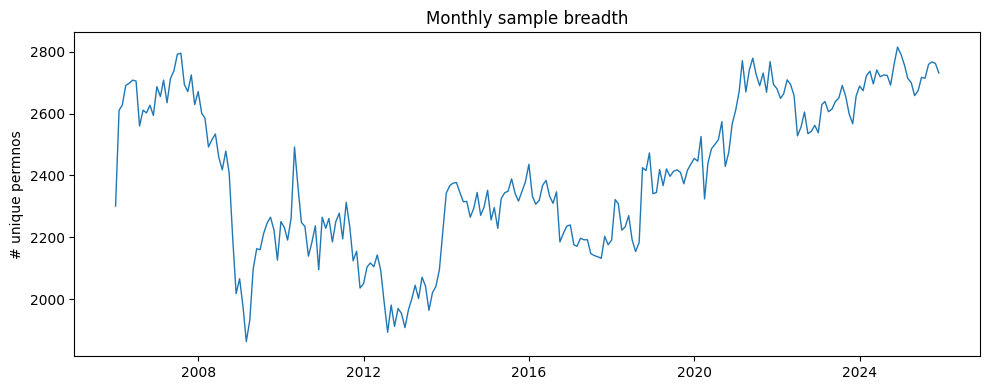

In [3]:
# Plot sample breadth: number of unique permnos per month
n_month = hlr_panel.groupby("yyyymm")["permno"].nunique().reset_index(name="n_permno")
n_month["dt"] = pd.to_datetime(n_month["yyyymm"].astype(str), format="%Y%m")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(n_month["dt"], n_month["n_permno"], lw=1.0)
ax.set_xlabel("")
ax.set_ylabel("# unique permnos")
ax.set_title("Monthly sample breadth")
ax.grid(False)
plt.tight_layout()
plt.show()


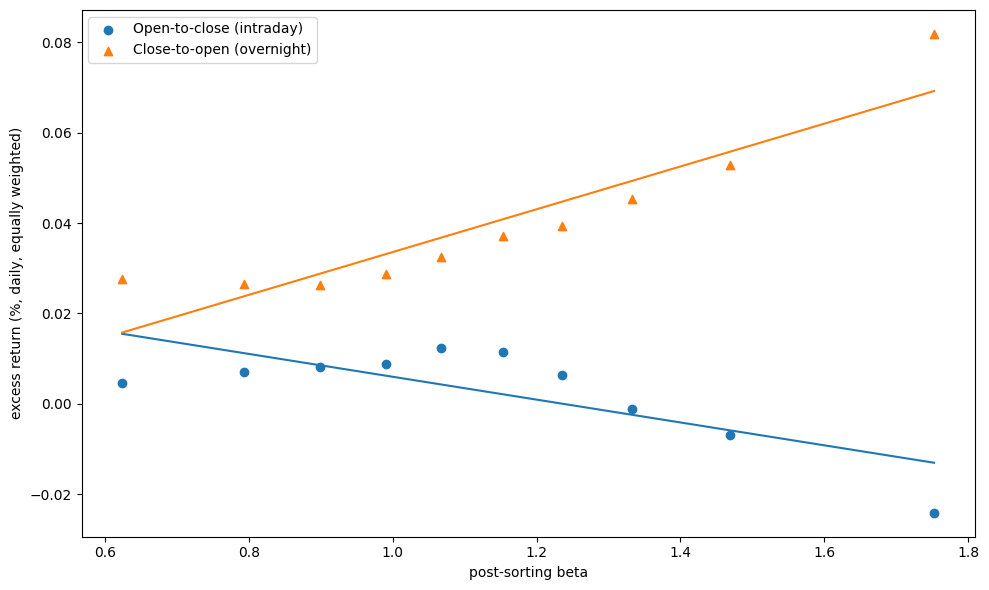

In [4]:
# Plot 1: EW full-sample replication (intraday vs overnight vs post-sorting beta)
res_ew = plot_hlr_replication(
    hlr_panel,
    ff6_daily,
    eqw=True,
    k_groups=k_groups,
    save_filename="replication_HLR2020JFE_ew.pdf",
)


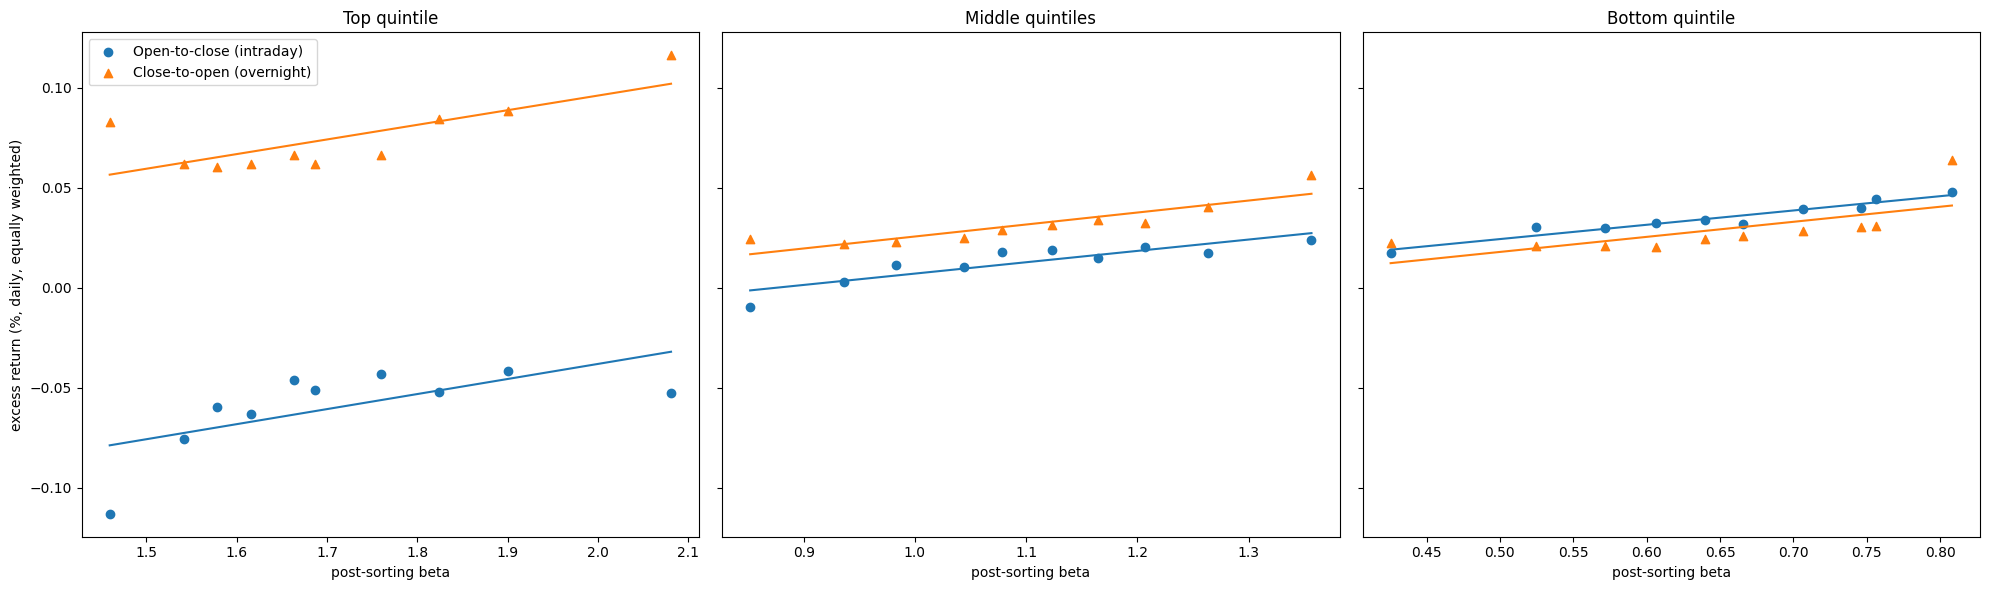

In [5]:
# Plot 2: EW news-sorted replication (top/middle/bottom news quintiles)
res_bucket_ew = plot_hlr_news_quintiles(
    hlr_panel,
    ff6_daily,
    eqw=True,
    k_groups=k_groups,
    low=0.2,
    high=0.8,
    save_filename="replication_HLR2020JFE_gammas_ew.pdf",
)


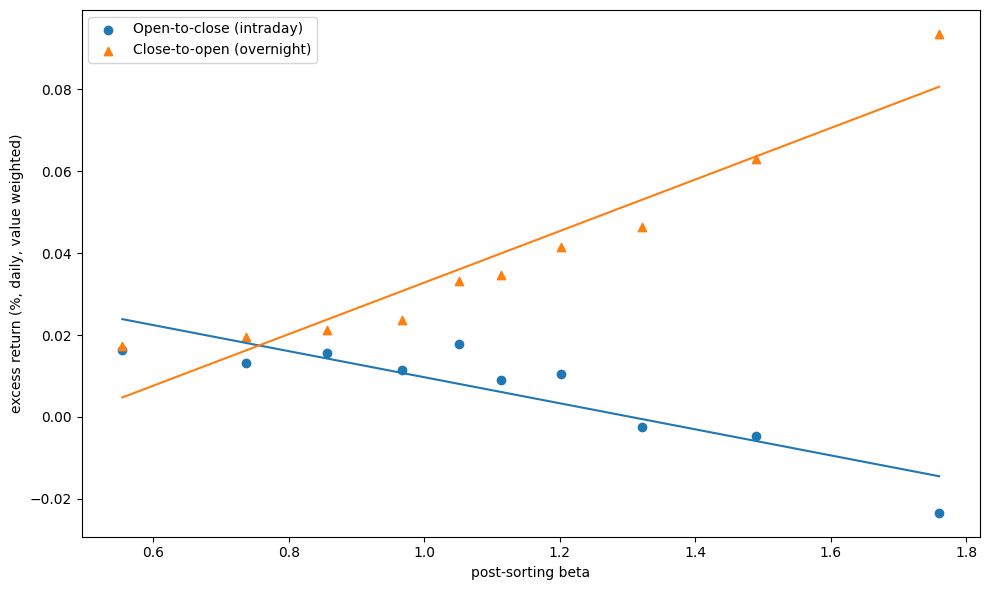

In [6]:
# Plot 3: VW full-sample replication (intraday vs overnight vs post-sorting beta)
res_vw = plot_hlr_replication(
    hlr_panel,
    ff6_daily,
    eqw=False,
    k_groups=k_groups,
    save_filename="replication_HLR2020JFE_vw.pdf",
)


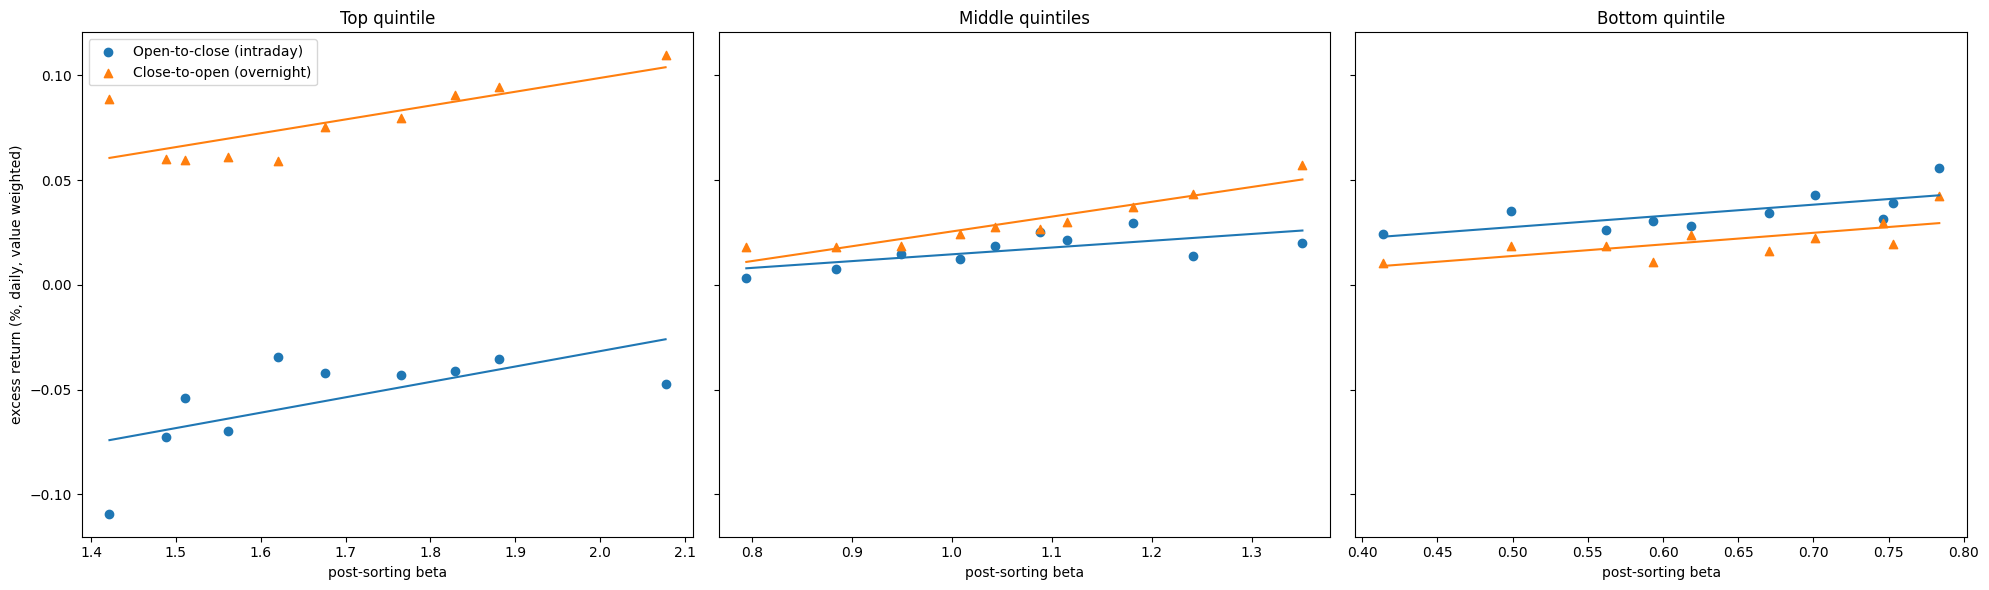

In [7]:
# Plot 4: VW news-sorted replication (top/middle/bottom news quintiles)
res_bucket_vw = plot_hlr_news_quintiles(
    hlr_panel,
    ff6_daily,
    eqw=False,
    k_groups=k_groups,
    low=0.2,
    high=0.8,
    save_filename="replication_HLR2020JFE_gammas_vw.pdf",
)


In [8]:
# FM regressions by news quintiles (EW): full/top/middle/bottom
fm_ew = run_hlr_fm_by_news_quintiles(
    hlr_panel,
    eqw=True,
    beta_col="beta_sort",
    k_groups=k_groups,
    lags=10,
    low=0.2,
    high=0.8,
)


********************full-sample: equal-weight********************
[night_ex]  Mean(Intercept) = -0.004, t(NW) = -0.70
[night_ex]  Mean(beta)       = 0.037, t(NW) = 4.98
[night_ex]  Avg adj-R^2     = 0.5537
[day_ex]  Mean(Intercept) = 0.025, t(NW) = 2.48
[day_ex]  Mean(beta)       = -0.019, t(NW) = -1.34
[day_ex]  Avg adj-R^2     = 0.5859
********************top-news quintile: equal-weight********************
[night_ex]  Mean(Intercept) = 0.032, t(NW) = 2.58
[night_ex]  Mean(beta)       = 0.028, t(NW) = 3.95
[night_ex]  Avg adj-R^2     = 0.2627
[day_ex]  Mean(Intercept) = -0.106, t(NW) = -4.26
[day_ex]  Mean(beta)       = 0.033, t(NW) = 2.34
[day_ex]  Avg adj-R^2     = 0.2581
********************middle-news quintiles: equal-weight********************
[night_ex]  Mean(Intercept) = -0.000, t(NW) = -0.02
[night_ex]  Mean(beta)       = 0.027, t(NW) = 4.27
[night_ex]  Avg adj-R^2     = 0.4024
[day_ex]  Mean(Intercept) = -0.015, t(NW) = -1.29
[day_ex]  Mean(beta)       = 0.026, t(NW) = 2.39
[

In [9]:
# FM regressions by news quintiles (VW): full/top/middle/bottom
fm_vw = run_hlr_fm_by_news_quintiles(
    hlr_panel,
    eqw=False,
    beta_col="beta_sort",
    k_groups=k_groups,
    lags=10,
    low=0.2,
    high=0.8,
)


********************full-sample: value-weight********************
[night_ex]  Mean(Intercept) = -0.023, t(NW) = -3.14
[night_ex]  Mean(beta)       = 0.054, t(NW) = 5.73
[night_ex]  Avg adj-R^2     = 0.4464
[day_ex]  Mean(Intercept) = 0.040, t(NW) = 3.28
[day_ex]  Mean(beta)       = -0.029, t(NW) = -1.85
[day_ex]  Avg adj-R^2     = 0.4530
********************top-news quintile: value-weight********************
[night_ex]  Mean(Intercept) = 0.038, t(NW) = 2.33
[night_ex]  Mean(beta)       = 0.027, t(NW) = 2.66
[night_ex]  Avg adj-R^2     = 0.1796
[day_ex]  Mean(Intercept) = -0.109, t(NW) = -4.20
[day_ex]  Mean(beta)       = 0.037, t(NW) = 2.32
[day_ex]  Avg adj-R^2     = 0.1748
********************middle-news quintiles: value-weight********************
[night_ex]  Mean(Intercept) = -0.011, t(NW) = -1.29
[night_ex]  Mean(beta)       = 0.036, t(NW) = 4.12
[night_ex]  Avg adj-R^2     = 0.2955
[day_ex]  Mean(Intercept) = 0.003, t(NW) = 0.23
[day_ex]  Mean(beta)       = 0.014, t(NW) = 1.13
[da

In [10]:
# Export FM summary table (EW vs VW) to LaTeX
print_latex_hlr_fm_table(
    fm_ew=fm_ew,
    fm_vw=fm_vw,
    lags=10,
    latex_filename="hlr_fm_ew_vw.tex",
)
